# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/jimmyzheng/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32)

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32)

    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes = len(class_names)

print("Training set:", X_train.shape, y_train.shape)
print("Test set    :", X_test.shape, y_test.shape)
print("num_features:", num_features)
print("num_classes :", num_classes)


Training set: (7352, 561) (7352,)
Test set    : (2947, 561) (2947,)
num_features: 561
num_classes : 6


## 4. Quick Inspection

In [5]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

train_counts = np.bincount(y_train, minlength=len(class_names))

summary_table = pd.DataFrame({
    "class_index": np.arange(len(class_names)),
    "class_name": class_names,
    "num_training_samples": train_counts,
})

summary_table


,class_index,class_name,num_training_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model
    
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 814us/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 822us/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 823us/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 804us/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 810us/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2388 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 810us/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/

### Training Curves

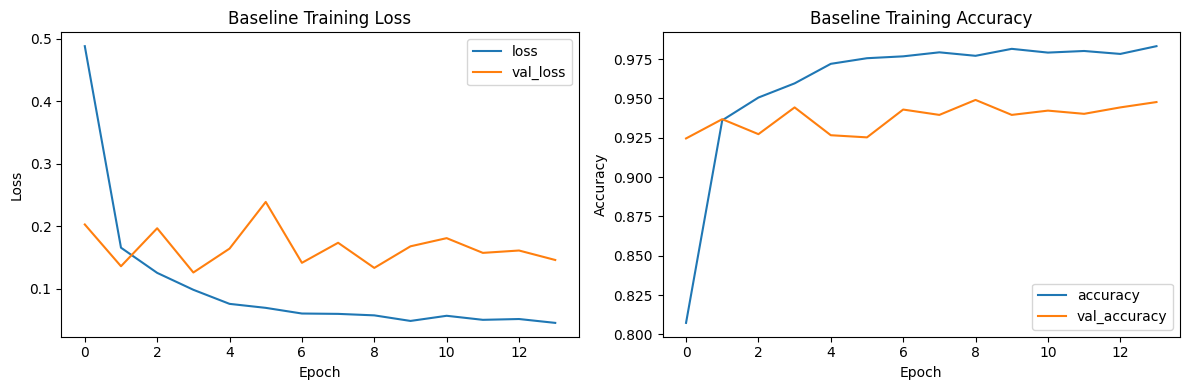

In [10]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

history_df = pd.DataFrame(history_baseline.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

Baseline Keras test accuracy: 0.9308

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.95      0.96      0.95       496
  WALKING_UPSTAIRS       0.96      0.91      0.93       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.95      0.86      0.90       491
          STANDING       0.84      0.96      0.90       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



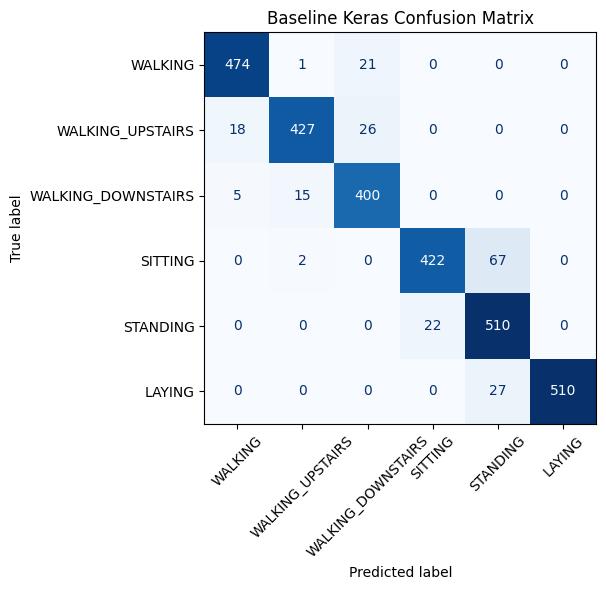

In [11]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

y_test_proba = baseline_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

baseline_test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Baseline Keras test accuracy: {baseline_test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Confusion Matrix")
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [12]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()
    
    raise NotImplementedError("Complete the FP32 conversion helper.")


## 8. Convert the Baseline Model to TensorFlow Lite

In [13]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

baseline_tflite = convert_to_tflite_fp32(baseline_model)

baseline_tflite_size_kb = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_tflite_acc, baseline_tflite_pred = evaluate_tflite_model(
    baseline_tflite, X_test, y_test
)

print(f"Baseline TFLite size: {baseline_tflite_size_kb:.2f} KB")
print(f"Baseline TFLite test accuracy: {baseline_tflite_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6xxxy2kx/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6xxxy2kx/assets
2026-04-18 16:47:35.356805: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 16:47:35.356816: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 16:47:35.357104: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6xxxy2kx
2026-04-18 16:47:35.357525: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 16:47:35.357529: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp6xxxy2kx
2026-04-18 16:47:35.358737: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-18 16:47:35.359127: I tensorflow/cc/saved_model/load

Baseline TFLite size: 726.72 KB
Baseline TFLite test accuracy: 0.9308


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [14]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = int(np.ceil((0.8 * len(X_train)) / batch_size))

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruned_model.summary()

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

history_pruned = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 256)               287490    
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 128)               65666     
 5 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 64)                16450     
 6 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 6)                 776       
 7 (PruneLowMagnitude)                                           
                                                                 
Total params: 370382 (1.41 MB)
Trainable params: 18541

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [15]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# Convert the pruned model with pruning wrappers 
pruned_wrapped_tflite = convert_to_tflite_fp32(pruned_model)

# save the model and evaluate it on X_test
pruned_wrapped_size_kb = save_binary_model(
    pruned_wrapped_tflite, "pruned_with_wrappers_fp32.tflite"
)
pruned_wrapped_acc, pruned_wrapped_pred = evaluate_tflite_model(
    pruned_wrapped_tflite, X_test, y_test
)

# strip the pruning wrappers
stripped_model = strip_pruning(pruned_model)

# convert the stripped model
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

# save the stripped sparse model and evaluate it on X_test
stripped_sparse_size_kb = save_binary_model(
    stripped_sparse_tflite, "pruned_stripped_sparse.tflite"
)
stripped_sparse_acc, stripped_sparse_pred = evaluate_tflite_model(
    stripped_sparse_tflite, X_test, y_test
)

print(f"Pruned model with wrappers size: {pruned_wrapped_size_kb:.2f} KB")
print(f"Pruned model with wrappers accuracy: {pruned_wrapped_acc:.4f}")

print(f"Stripped sparse model size: {stripped_sparse_size_kb:.2f} KB")
print(f"Stripped sparse model accuracy: {stripped_sparse_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9rn8jc8c/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9rn8jc8c/assets
2026-04-18 17:10:49.651426: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 17:10:49.651441: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 17:10:49.651526: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9rn8jc8c
2026-04-18 17:10:49.652672: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 17:10:49.652676: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9rn8jc8c
2026-04-18 17:10:49.655790: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 17:10:49.680838: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpk3lxbnb5/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpk3lxbnb5/assets


Pruned model with wrappers size: 1454.18 KB
Pruned model with wrappers accuracy: 0.9223
Stripped sparse model size: 338.85 KB
Stripped sparse model accuracy: 0.9223


2026-04-18 17:10:50.116242: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 17:10:50.116251: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 17:10:50.116320: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpk3lxbnb5
2026-04-18 17:10:50.116564: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 17:10:50.116567: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpk3lxbnb5
2026-04-18 17:10:50.117133: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 17:10:50.123871: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpk3lxbnb5
2026-04-

## 11. Part I Comparison: Accuracy and Model Size

In [16]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_rows = []

y_pruned_proba = pruned_model.predict(X_test, verbose=0)
y_pruned_pred = np.argmax(y_pruned_proba, axis=1)
pruned_accuracy = accuracy_score(y_test, y_pruned_pred)

part1_rows.append({
    "model": "Baseline TFLite",
    "file": "baseline_fp32.tflite",
    "size_kb": round(float(baseline_tflite_size_kb), 2),
    "accuracy": round(float(baseline_tflite_acc), 4),
})

part1_rows.append({
    "model": "Pruned TFLite (with mask)",
    "file": "pruned_with_wrappers_fp32.tflite",
    "size_kb": round(float(pruned_wrapped_size_kb), 2),
    "accuracy": round(float(pruned_wrapped_acc), 4),
})

part1_rows.append({
    "model": "Pruned Sparse TFLite",
    "file": "pruned_stripped_sparse.tflite",
    "size_kb": round(float(stripped_sparse_size_kb), 2),
    "accuracy": round(float(stripped_sparse_acc), 4),
})

part1_results = pd.DataFrame(part1_rows)

keras_reference = pd.DataFrame(
    [
        {
            "model": "Baseline Keras",
            "file": "-",
            "size_kb": np.nan,
            "accuracy": round(float(baseline_test_accuracy), 4),
        },
        {
            "model": "Pruned Keras (wrapped)",
            "file": "-",
            "size_kb": np.nan,
            "accuracy": round(float(pruned_accuracy), 4),
        },
    ]
)

part1_display = pd.concat([keras_reference, part1_results], ignore_index=True)
part1_display


,model,file,size_kb,accuracy
0,Baseline Keras,-,NaN,0.9308
1,Pruned Keras (wrapped),-,NaN,0.9223
2,Baseline TFLite,baseline_fp32.tflite,726.72,0.9308
3,Pruned TFLite (with mask),pruned_with_wrappers_fp32.tflite,1454.18,0.9223
4,Pruned Sparse TFLite,pruned_stripped_sparse.tflite,338.85,0.9223


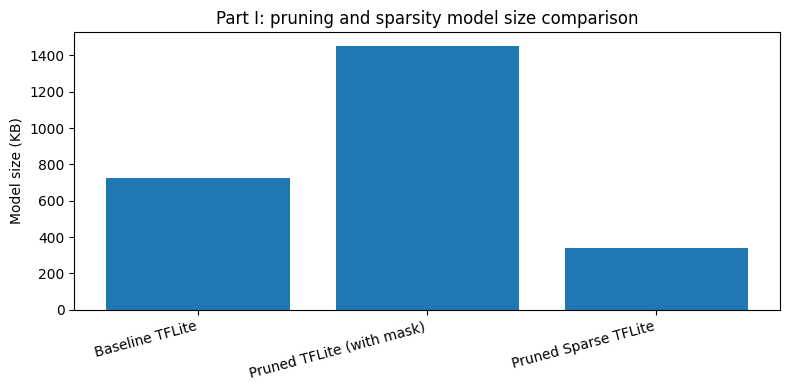

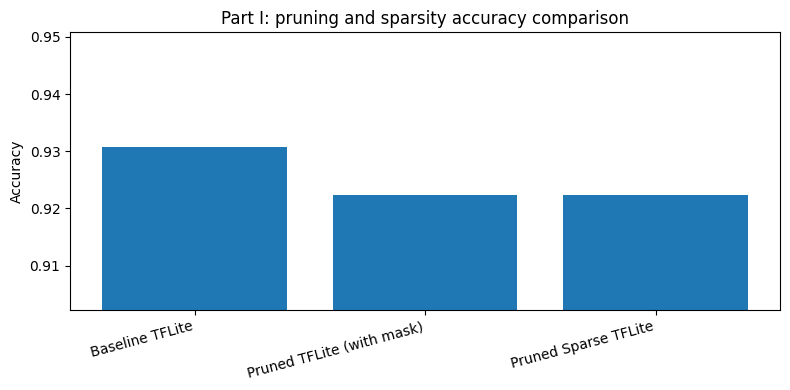

In [19]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

part1_plot_df = part1_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(part1_plot_df["model"], part1_plot_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("Part I: pruning and sparsity model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(part1_plot_df["model"], part1_plot_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Part I: pruning and sparsity accuracy comparison")
plt.ylim(
    max(0.0, part1_plot_df["accuracy"].min() - 0.02),
    min(1.0, part1_plot_df["accuracy"].max() + 0.02),
)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.91      0.92      0.91       420
           SITTING       0.95      0.84      0.89       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



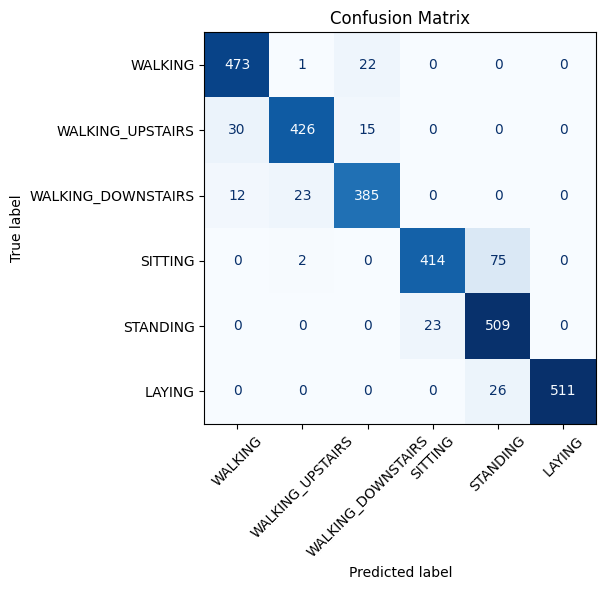

In [20]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

print("Classification Report:")
print(classification_report(y_test, stripped_sparse_pred, target_names=class_names))

cm_sparse = confusion_matrix(y_test, stripped_sparse_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sparse, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [21]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.


# convert the pruned model with mask 
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_with_mask_float16_tflite = converter.convert()

# save and evaluate the float16 model with mask
pruned_with_mask_float16_size_kb = save_binary_model(
    pruned_with_mask_float16_tflite,
    "pruned_model_with_mask_float16.tflite"
)
pruned_with_mask_float16_acc, pruned_with_mask_float16_pred = evaluate_tflite_model(
    pruned_with_mask_float16_tflite, X_test, y_test
)

print("Saved float16 quantized model (with mask).")

# convert the stripped sparse model
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()

# save and evaluate the stripped sparse model
stripped_sparse_float16_size_kb = save_binary_model(
    stripped_sparse_float16_tflite,
    "pruned_model_sparse_float16.tflite"
)
stripped_sparse_float16_acc, stripped_sparse_float16_pred = evaluate_tflite_model(
    stripped_sparse_float16_tflite, X_test, y_test
)

print("Saved float16 quantized model (stripped sparse).")

print(f"Pruned + Float16 size: {pruned_with_mask_float16_size_kb:.2f} KB")
print(f"Pruned + Float16 accuracy: {pruned_with_mask_float16_acc:.4f}")

print(f"Pruned Sparse + Float16 size: {stripped_sparse_float16_size_kb:.2f} KB")
print(f"Pruned Sparse + Float16 accuracy: {stripped_sparse_float16_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9603255q/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9603255q/assets
2026-04-18 17:35:19.786065: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 17:35:19.786079: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 17:35:19.786172: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9603255q
2026-04-18 17:35:19.787412: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 17:35:19.787416: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmp9603255q
2026-04-18 17:35:19.790700: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 17:35:19.815879: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Saved float16 quantized model (with mask).
INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpw8uvwre_/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpw8uvwre_/assets


Saved float16 quantized model (stripped sparse).
Pruned + Float16 size: 732.59 KB
Pruned + Float16 accuracy: 0.9223
Pruned Sparse + Float16 size: 223.71 KB
Pruned Sparse + Float16 accuracy: 0.9223


2026-04-18 17:35:20.250372: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 17:35:20.250382: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 17:35:20.250458: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpw8uvwre_
2026-04-18 17:35:20.250715: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 17:35:20.250718: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpw8uvwre_
2026-04-18 17:35:20.251369: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 17:35:20.258466: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpw8uvwre_
2026-04-

## 12. Part II Comparison: Accuracy and Model Size

In [22]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_rows = []

part2_rows.append({
    "model": "Pruned FP32 (with mask)",
    "file": "pruned_with_wrappers_fp32.tflite",
    "size_kb": round(float(pruned_wrapped_size_kb), 2),
    "accuracy": round(float(pruned_wrapped_acc), 4),
})

part2_rows.append({
    "model": "Stripped Sparse FP32",
    "file": "pruned_stripped_sparse.tflite",
    "size_kb": round(float(stripped_sparse_size_kb), 2),
    "accuracy": round(float(stripped_sparse_acc), 4),
})

part2_rows.append({
    "model": "Pruned + Float16 (with mask)",
    "file": "pruned_model_with_mask_float16.tflite",
    "size_kb": round(float(pruned_with_mask_float16_size_kb), 2),
    "accuracy": round(float(pruned_with_mask_float16_acc), 4),
})

part2_rows.append({
    "model": "Stripped Sparse + Float16",
    "file": "pruned_model_sparse_float16.tflite",
    "size_kb": round(float(stripped_sparse_float16_size_kb), 2),
    "accuracy": round(float(stripped_sparse_float16_acc), 4),
})

part2_results = pd.DataFrame(part2_rows)
part2_results


,model,file,size_kb,accuracy
0,Pruned FP32 (with mask),pruned_with_wrappers_fp32.tflite,1454.18,0.9223
1,Stripped Sparse FP32,pruned_stripped_sparse.tflite,338.85,0.9223
2,Pruned + Float16 (with mask),pruned_model_with_mask_float16.tflite,732.59,0.9223
3,Stripped Sparse + Float16,pruned_model_sparse_float16.tflite,223.71,0.9223


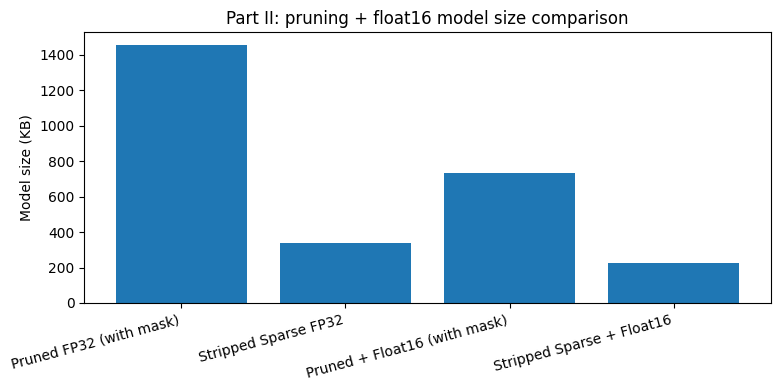

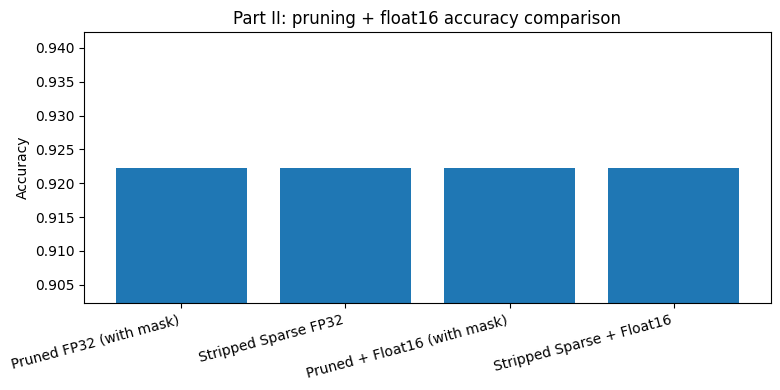

In [23]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

part2_plot_df = part2_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(part2_plot_df["model"], part2_plot_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("Part II: pruning + float16 model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(part2_plot_df["model"], part2_plot_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Part II: pruning + float16 accuracy comparison")
plt.ylim(
    max(0.0, part2_plot_df["accuracy"].min() - 0.02),
    min(1.0, part2_plot_df["accuracy"].max() + 0.02),
)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.91      0.92      0.91       420
           SITTING       0.95      0.84      0.89       491
          STANDING       0.83      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



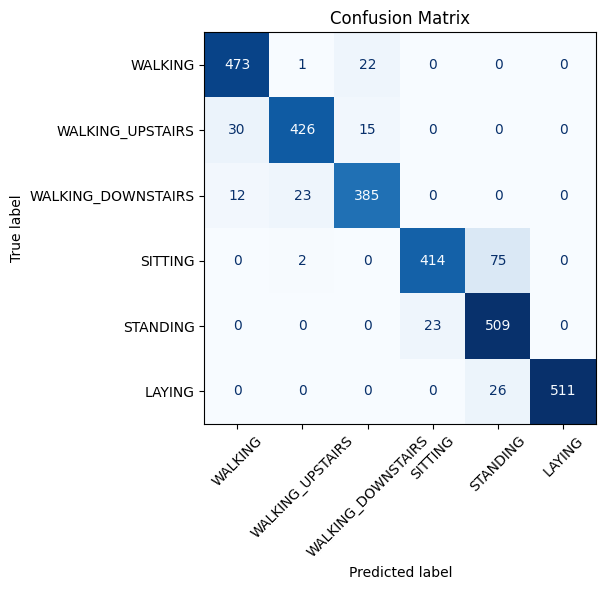

In [24]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

print("Classification Report:")
print(classification_report(y_test, stripped_sparse_float16_pred, target_names=class_names))

cm_sparse_float16 = confusion_matrix(y_test, stripped_sparse_float16_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sparse_float16,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
    No. The baseline TFlite has a file size of 726.72, but the pruned TFlite has a file size of 1454.18 kB, which is much larger.
 
2. Why does `strip_pruning(...)` matter before export?
    because it can remove the wrappers and masks, which is only useful during training. Strip them will make the model smaller and much cleaner with only sparse weights present.

3. Which model had the smallest file size in this notebook?
   The Stripped Sparse + Float16 model has the smallest file size of only 223.71 kB.

4. Did float16 quantization noticeably change the test accuracy?
    No, the test accuracy stays in 0.9223.

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

   I would choose the Stripped Sparse + Float16 model, because it has the smallest file size and a good accuracy compared to other models.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
